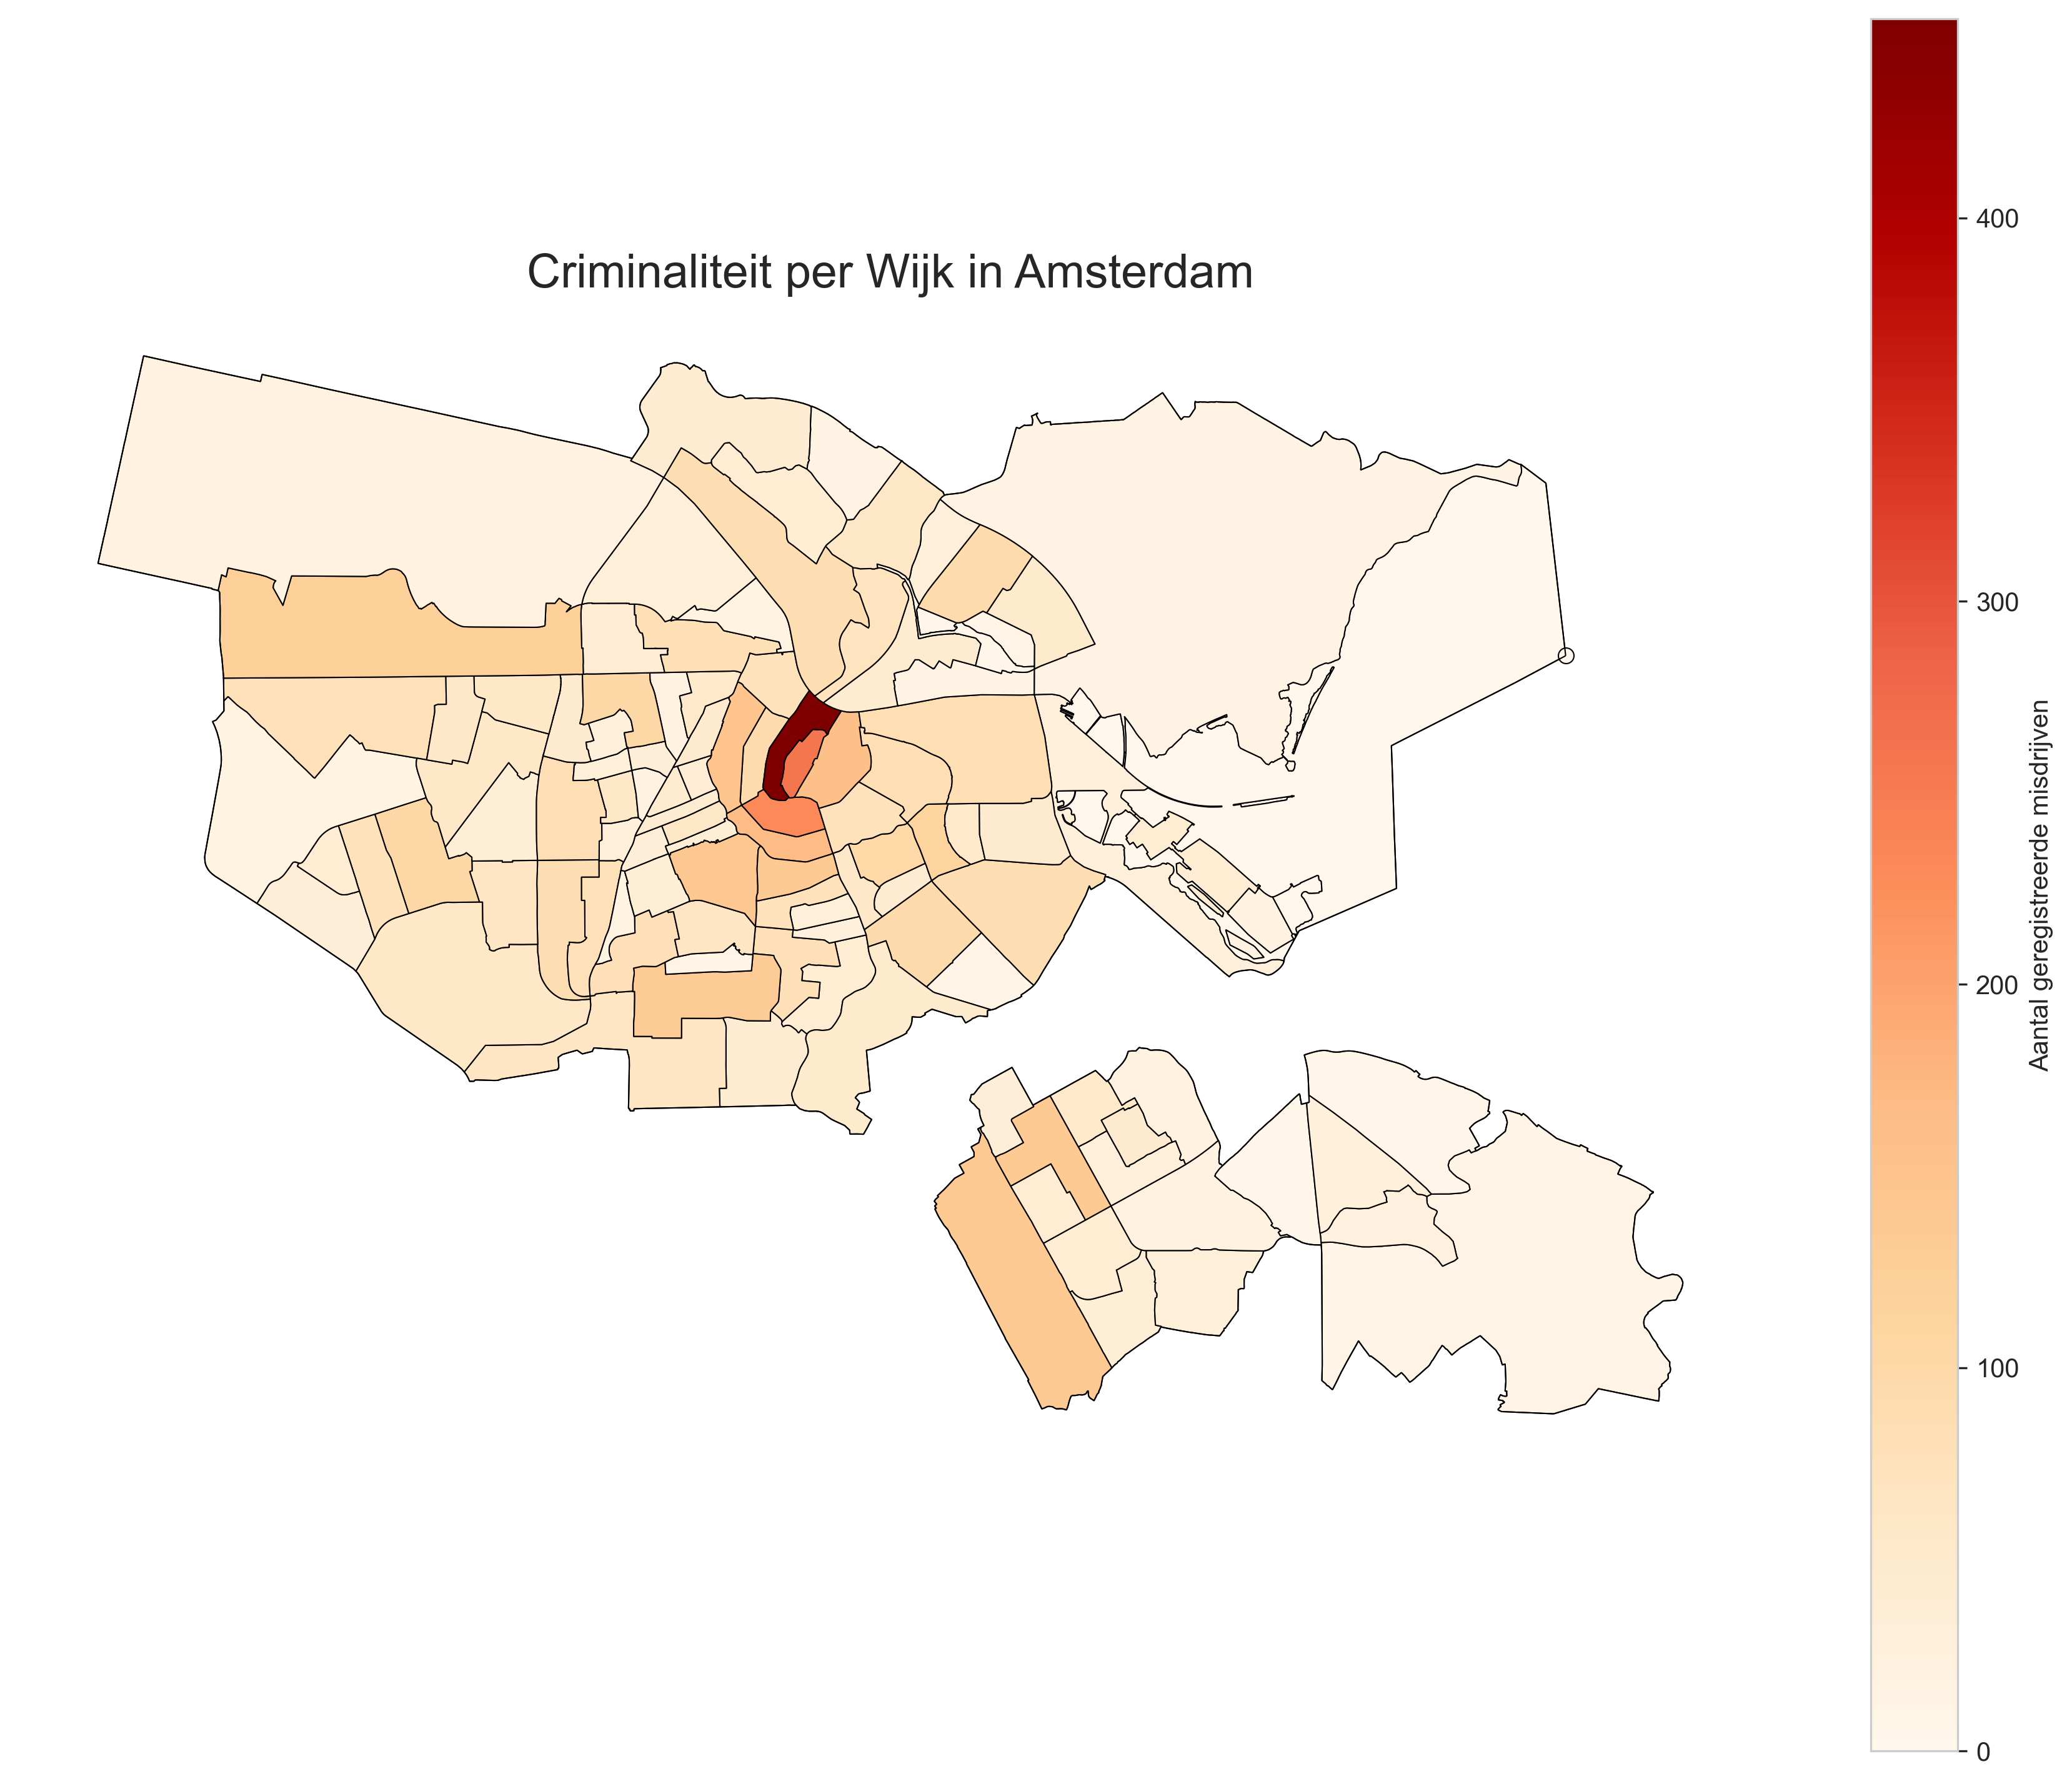

In [10]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- STAP 1: DATA LADEN ---

# 1. Je kaartmateriaal (Wijken in Amsterdam)
gemeenten = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer="gemeenten")
amsterdam_grens = gemeenten[gemeenten['gemeentenaam'] == 'Amsterdam']

wijken = gpd.read_file("data/wijken_en_gemeenten.gpkg", layer="wijken")
amsterdam_wijken = gpd.clip(wijken, amsterdam_grens)

# 2. Je misdaad data laden

import numpy as np
df_crime = pd.read_csv("data/df_crime_average_per_year.csv") # Check even of dit puntkomma moet zijn!

# --- STAP 3: KOPPELEN (MERGE) ---
# We koppelen de Excel-data (rechts) aan de kaart (links).
# Omdat de namen van de kolommen verschillen ('wijknaam' vs 'Wijk'), geven we dat specifiek aan.
amsterdam_crime = amsterdam_wijken.merge(
    df_crime,
    left_on='wijknaam',       # Naam in de kaart (GPKG)
    right_on='Wijk',          # Naam in jouw CSV
    how='left'                # Behoud alle wijken op de kaart, ook als er geen crime data is
)

# Vul wijken zonder data (NaN) op met 0, zodat ze niet wit blijven op de kaart
amsterdam_crime['Totaal misdrijven'] = amsterdam_crime['Totaal misdrijven'].fillna(0)
# --- STAP 3: VISUALISEREN (CHOROPLETH) ---

fig, ax = plt.subplots(figsize=(15, 12), dpi=300)

# De plot functie doet het zware werk
amsterdam_crime.plot(
    column='Totaal misdrijven', # De kolom die de kleur bepaalt
    cmap='OrRd',                # Kleurenschema: Oranje naar Rood (OrRd) of 'Reds'
    linewidth=0.5,              # Dikte van de lijntjes tussen wijken
    edgecolor='black',          # Kleur van de lijntjes
    legend=True,                # Laat een balk zien met wat de kleuren betekenen
    legend_kwds={'label': "Aantal geregistreerde misdrijven"}, # Label bij de balk
    ax=ax
)

ax.set_title("Criminaliteit per Wijk in Amsterdam", fontsize=18)
ax.set_axis_off()

plt.show()

/Users/yoran/miniconda3/lib/python3.12/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 10 classes. Setting k to 9.
  self.bins = quantile(y, k=k)


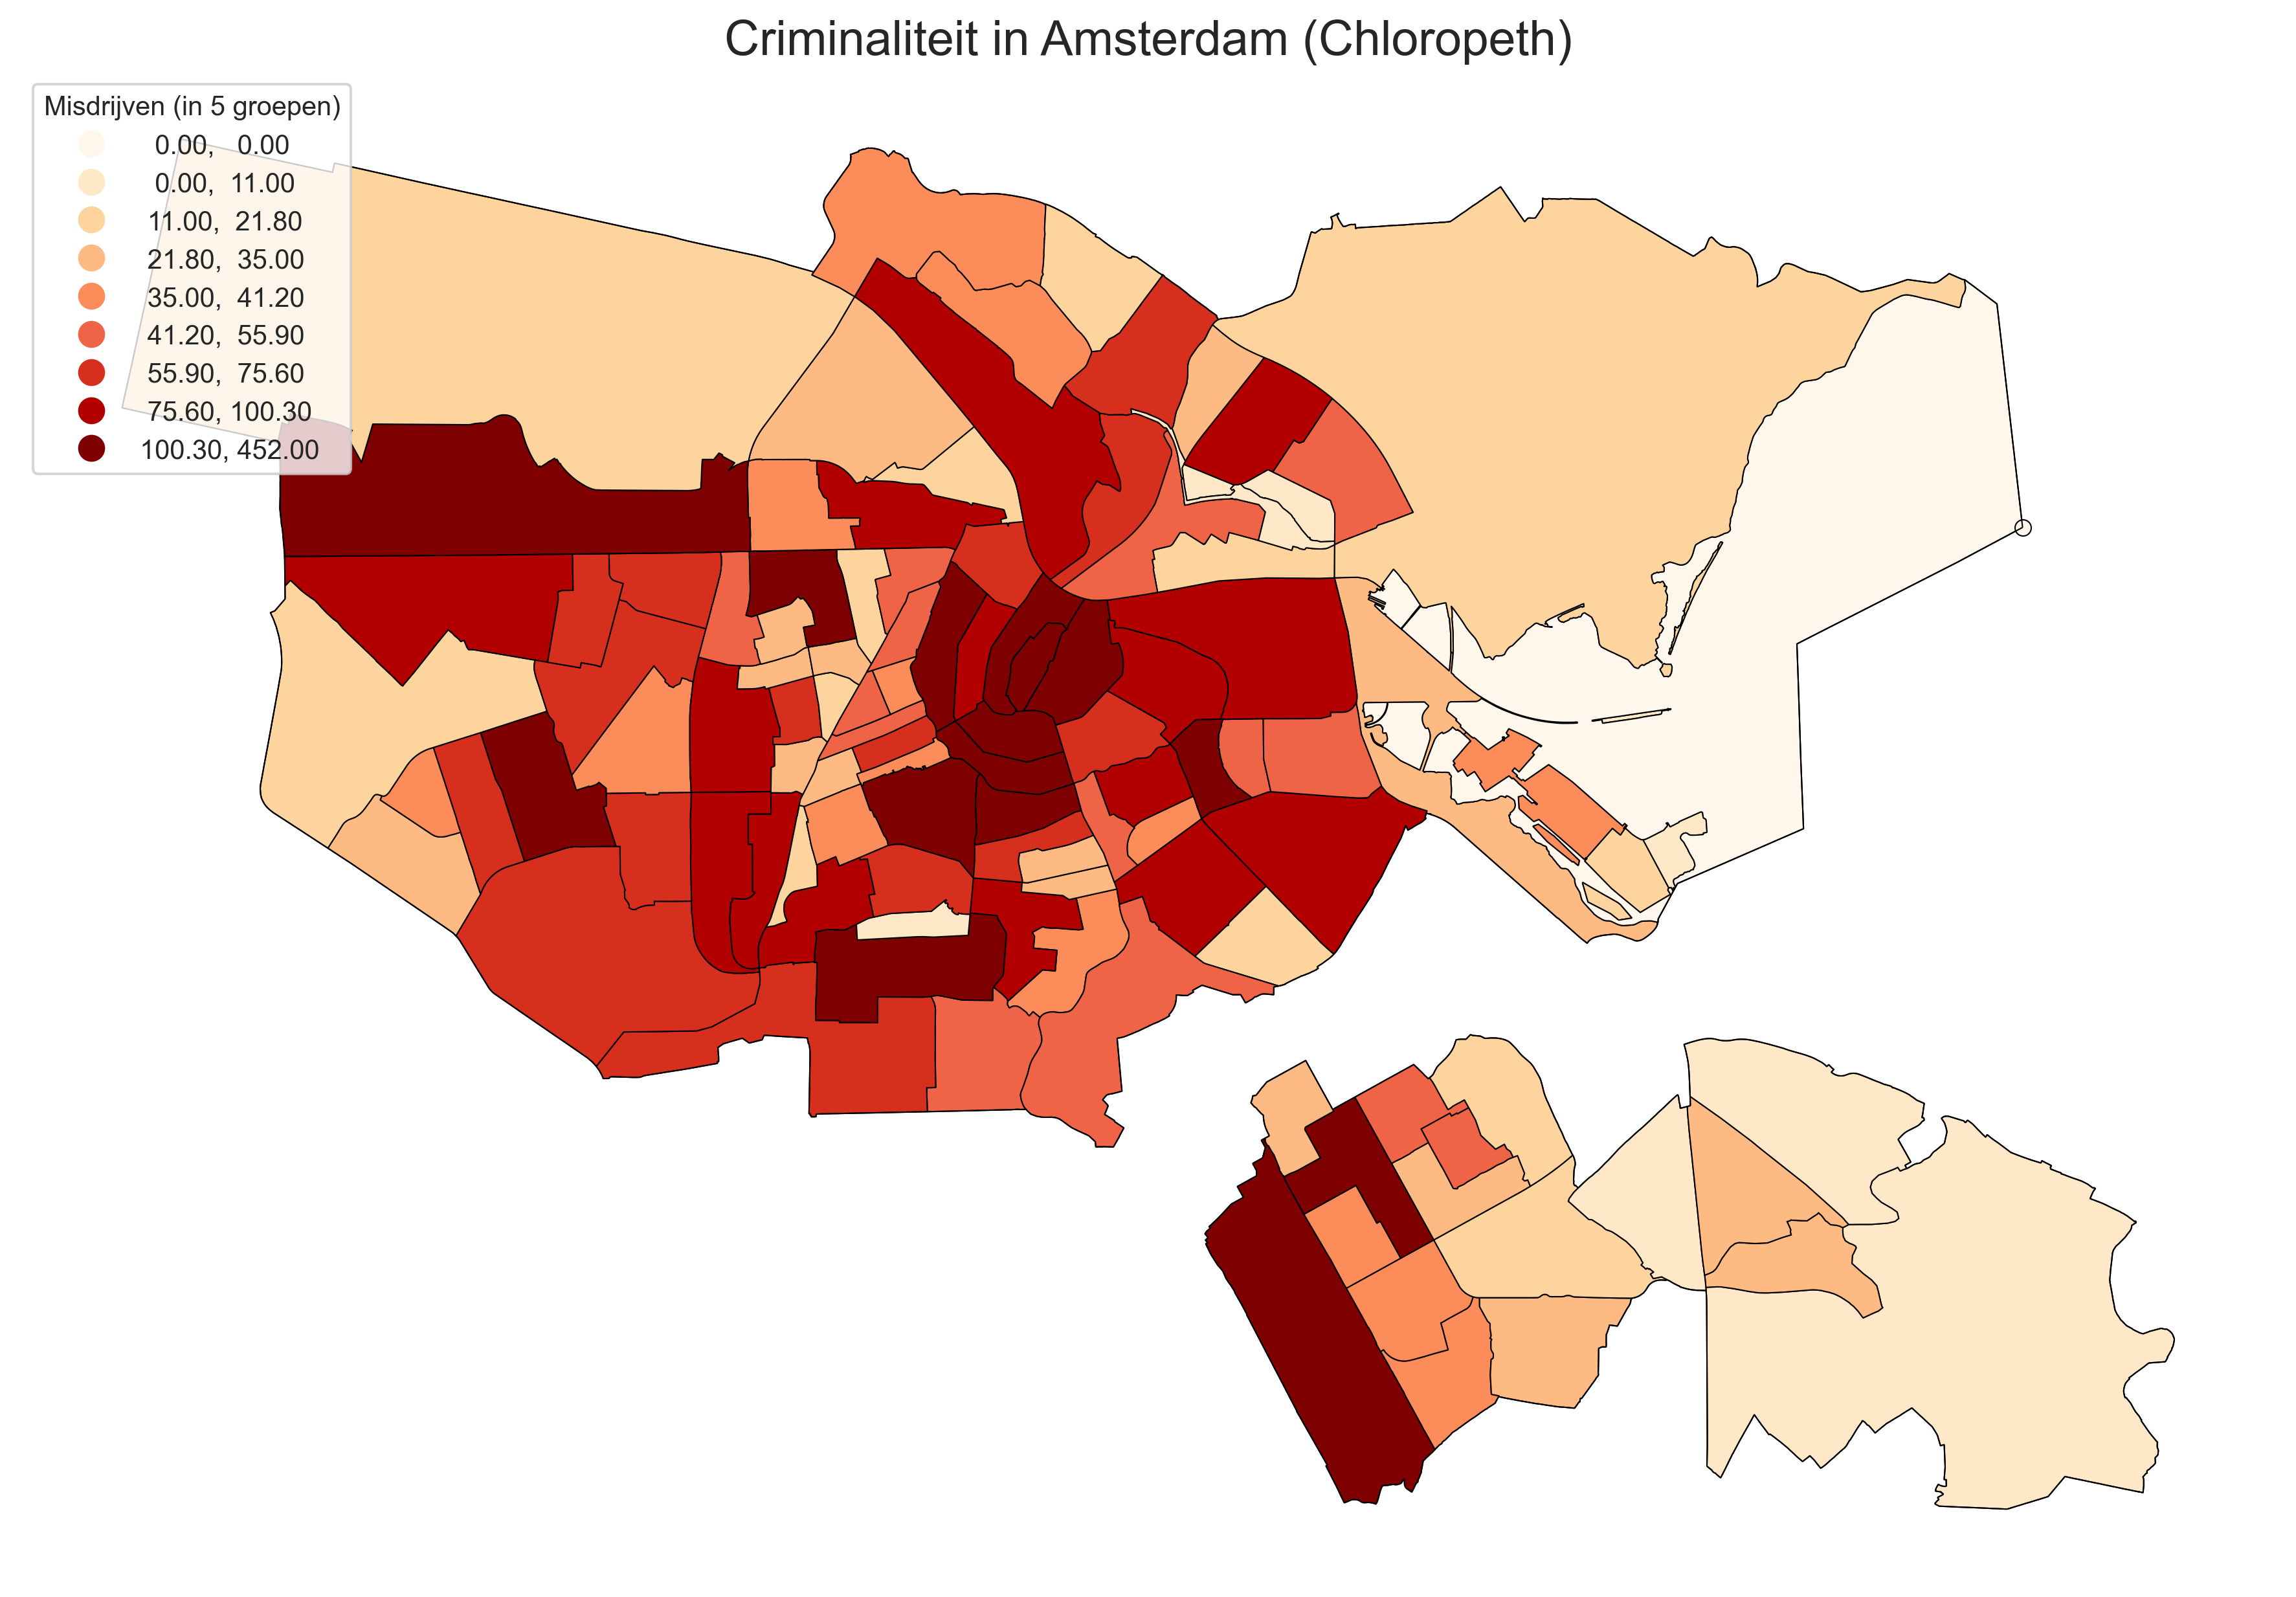

In [14]:
fig, ax = plt.subplots(figsize=(15, 12), dpi=300)

amsterdam_crime.plot(
    column='Totaal misdrijven',
    scheme='quantiles',     # <--- DIT IS DE TRUC: Verdeelt in groepen
    k=10,                    # Maak 5 groepen (Van 'Veiligste 20%' tot 'Onveiligste 20%')
    cmap='OrRd',            # Roodverloop
    linewidth=0.5,
    edgecolor='black',      # Iets donkerdere lijnen voor contrast
    legend=True,
    legend_kwds={'loc': 'upper left', 'title': "Misdrijven (in 5 groepen)"},
    missing_kwds={'color': 'lightgrey', 'label': 'Geen data'},
    ax=ax
)

ax.set_title("Criminaliteit in Amsterdam (Chloropeth)", fontsize=18)
ax.set_axis_off()

plt.show()